<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/QFT023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

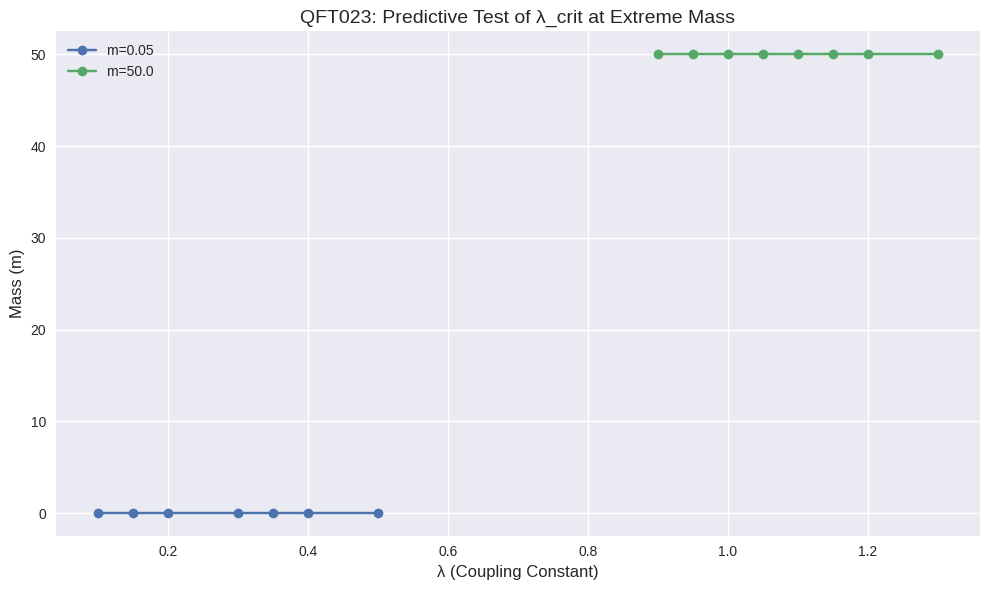

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
timesteps = 500
lattice_size = 100
mass_values = [0.05, 50.0]
lambda_values = np.arange(0.1, 2.05, 0.05)
damping = 0.995

# Stability thresholds
variance_thresh = 0.05
coherence_thresh = 0.1

# Initialize results
survivors = {m: [] for m in mass_values}

# Simulation functions
def initialize_lattice(size):
    return np.random.rand(size).astype(np.float32)

def entropy_gradient(state):
    return np.gradient(state).astype(np.float32)

def holographic_flux(state):
    grad = np.gradient(np.gradient(state))
    return grad.astype(np.float32)

def update_lattice(state, grad_S, flux_H, λ):
    update = -grad_S + λ * flux_H
    update *= damping
    return state + update.astype(np.float32)

def check_stability(history):
    final = np.array(history[-100:])
    variance = np.var(final, axis=0).mean()
    coherence = np.abs(np.mean(np.diff(final, axis=0))).mean()
    return variance < variance_thresh and coherence < coherence_thresh

# Run simulation
for m in mass_values:
    for λ in lambda_values:
        state = initialize_lattice(lattice_size)
        history = []
        for t in range(timesteps):
            grad_S = entropy_gradient(state)
            flux_H = holographic_flux(state) * (m / (1 + m))
            state = update_lattice(state, grad_S, flux_H, λ)
            state = np.clip(state, 0.0, 1.0)
            history.append(state.copy())
        if check_stability(history):
            survivors[m].append(λ)

# Plot results
plt.style.use("seaborn-v0_8")
fig, ax = plt.subplots(figsize=(10, 6))
for m in mass_values:
    ax.plot(survivors[m], [m]*len(survivors[m]), 'o-', label=f"m={m}")
ax.set_xlabel("λ (Coupling Constant)", fontsize=12)
ax.set_ylabel("Mass (m)", fontsize=12)
ax.set_title("QFT023: Predictive Test of λ_crit at Extreme Mass", fontsize=14)
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()
